### GNN

In [1]:
"""
GNN Flood Forecasting Model (PyTorch Geometric + PyTorch)
Predicts streamflow 24 hours ahead for all sites simultaneously,
using the river network graph to share information between connected gauges.

Requires:
    uv add torch-geometric
    (installs torch_geometric, torch_scatter, torch_sparse)
"""
import torch
import torch.nn as nn
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from torch_geometric.nn import GCNConv

from src.preprocessing.preprocessing import processor

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

d:\Flood-Forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Same feature set as the LSTM notebooks so results are comparable.

QUICK_TEST = True  # Single batch per epoch to validate the full pipeline

STATIC_FEATURES = [
    "longitude", "latitude", "DRAIN_SQKM", "artificial_path_pct",
    "wb5100_ann_mm", "snw_pc_syr", "snow_ice_nlcd06", "barren_nlcd06",
    "mains100_plant", "hga", "hgc", "bulk_density_avg", "elev_max_m", "aspect_deg",
]

DYNAMIC_FEATURES = [
    "streamflow_cfs_mean", "streamflow_cfs_max", "streamflow_cfs_min",
    "gage_height_ft_mean",
    "precipitation_mm",
    "temperature_c",
    "potential_evaporation_mm",
    "specific_humidity_kgkg",
    "shortwave_radiation_wm2",
    "longwave_radiation_wm2",
    "wind_speed_ms",
    "surface_pressure_pa",
    "cape_jkg",
    "convective_precip_fraction",
]

TARGET = "streamflow_cfs_mean"

config = {
    "input_cols": DYNAMIC_FEATURES + STATIC_FEATURES,
    "static_cols": STATIC_FEATURES,
    "target": "streamflow_cfs_target_24h",
    "train_split": 0.8,
    "val_split": 0.9,
    "table": "wandb.flood_model",
    "lag_window": 1,
    "frequency": "hourly",
    "split_time_days": 30,
    "site_scaling": False,
}

# GNN-specific hyperparameters
GNN_CONFIG = {
    "window_size": 72,       # hours of history fed into the GRU (matches LSTM)
    "gcn_hidden": 32,        # embedding size output by each GCN layer
    "gru_hidden": 64,        # GRU hidden size
    "n_gcn_layers": 2,       # number of GCN rounds (= receptive field in hops)
    "dropout": 0.2,
    "lr": 1e-3,
    "epochs": 1 if QUICK_TEST else 50,
    "batch_size": 32,
    "patience": 8,
}

In [ ]:
# ── Step 1: Get target site list from W&B artifact ───────────────────────────
import wandb
api = wandb.Api(timeout=60)
artifact = api.artifact(
    "connorjsmith28-rice-university/flood-forecasting/flood-dataset-top30:latest"
)
art_dir = artifact.download()
_top30_df = pl.read_parquet(f"{art_dir}/flood_model_top30.parquet")
TARGET_SITES = sorted(_top30_df["site_id"].unique().cast(pl.Utf8).to_list())
del _top30_df
print(f"Target sites (from top-30 artifact): {len(TARGET_SITES)}")

# ── Step 2: Build graph topology from gage_connections.csv ───────────────────
GAGE_CSV = "../../../data/gage_connections.csv"
gage_df = pl.read_csv(GAGE_CSV, schema_overrides={
    "gage_id": pl.Utf8, "upstream_gage": pl.Utf8,
    "upstream_gage_mainline": pl.Utf8, "upstream_gage_trib": pl.Utf8,
})

parent_of: dict[str, str] = {}
gage_coords: dict[str, tuple[float, float]] = {}
all_csv_ids: set[str] = set()
for row in gage_df.iter_rows(named=True):
    gid = str(row["gage_id"]).strip()
    all_csv_ids.add(gid)
    gage_coords[gid] = (row["lat"], row["lon"])
    upstream = row["upstream_gage"]
    if upstream is not None and str(upstream).strip():
        parent_of[gid] = str(upstream).strip()

target_site_ids = set(TARGET_SITES) & all_csv_ids
graph_sites = set(target_site_ids)
for site in list(target_site_ids):
    current = site
    while current in parent_of:
        ancestor = parent_of[current]
        if ancestor in graph_sites:
            break
        graph_sites.add(ancestor)
        current = ancestor

ALL_GRAPH_SITES = sorted(graph_sites)
print(f"Graph sites: {len(ALL_GRAPH_SITES)} "
      f"({len(graph_sites) - len(target_site_ids)} upstream)")

# ── Step 3: Load data from DuckDB for all graph sites ───────────────────────
config["sites"] = ALL_GRAPH_SITES
pcr = processor(config)
pcr.pull_duckdb()

data_site_ids = set(pcr.df["site_id"].unique().cast(pl.Utf8).to_list())
print(f"Loaded {len(data_site_ids)} sites from DuckDB "
      f"({len(graph_sites) - len(data_site_ids)} relay with zeros)")
print(pcr.df.shape)

train_X, val_X, test_X, train_y, val_y, test_y = pcr.return_outputs()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\connor\_netrc.
wandb: Downloading large artifact 'flood-dataset-top30:latest', 145.19MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.7 (211.0MB/s)


Target sites (from top-30 artifact): 37
Graph sites: 59 (22 upstream)


In [ ]:
# ── Check per-site data availability ─────────────────────────────────────────
# Strict timestamp intersection across many sites often yields 0 overlap
# (different sites have slightly different hour grids or gaps).
# Instead, build_graph_sequences truncates to the minimum per-site row count.

for name, X_split in [("train", train_X), ("val", val_X), ("test", test_X)]:
    ids = X_split["site_id"].unique().to_list()
    counts = [X_split.filter(X_split["site_id"] == s).shape[0] for s in ids]
    print(f"{name}: {len(ids)} sites, {min(counts)}-{max(counts)} timesteps/site")

train: 35 sites, 9672-113089 timesteps/site
val: 35 sites, 1220-14119 timesteps/site
test: 35 sites, 1196-14126 timesteps/site


Dataset sites: 37,  sample: ['06036650', '06211000', '06700000']
Matched 37/37 dataset sites to gage_connections.csv
Total graph nodes: 59  (22 upstream relay)
Dataset node indices: [6, 7, 8, 11, 12, 13, 15, 16, 17, 18, 20, 22, 24, 25, 27, 28, 30, 31, 33, 34, 38, 39, 40, 42, 43, 44, 45, 46, 48, 51, 52, 53, 54, 55, 56, 57, 58]
Edges: 52 (undirected)
⚠ 19 isolated nodes


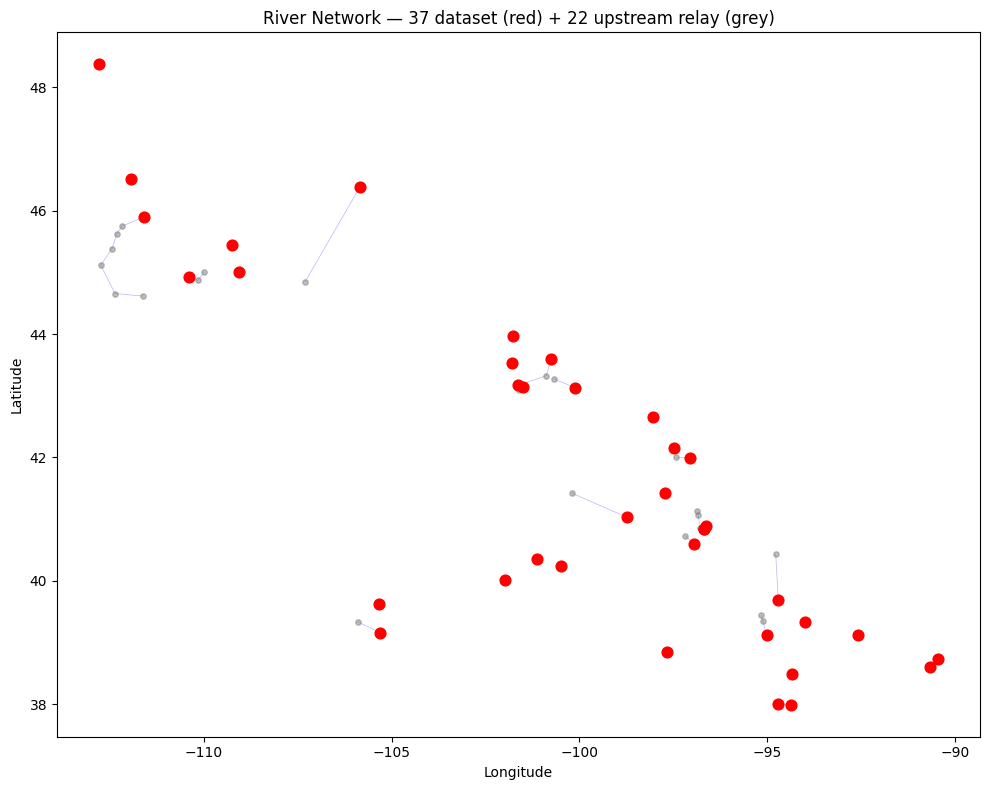

In [ ]:
# ── Build edge_index and node masks ──────────────────────────────────────────
# graph_sites, parent_of, gage_coords, target_site_ids, data_site_ids
# are all computed in cell 3.

sites_ordered = sorted(graph_sites)
site_to_idx = {s: i for i, s in enumerate(sites_ordered)}
num_nodes = len(sites_ordered)

# dataset_node_mask: only TARGET sites (used for loss and evaluation)
dataset_node_indices = sorted(
    [site_to_idx[s] for s in target_site_ids if s in site_to_idx]
)
dataset_node_mask = torch.zeros(num_nodes, dtype=torch.bool)
dataset_node_mask[dataset_node_indices] = True
dataset_sites_ordered = [sites_ordered[i] for i in dataset_node_indices]

data_node_indices = sorted(
    [site_to_idx[s] for s in data_site_ids if s in site_to_idx]
)

print(f"Total graph nodes: {num_nodes}")
print(f"  With data: {len(data_node_indices)}")
print(f"  Target (loss/eval): {len(dataset_node_indices)}")
print(f"  Relay (zeros): {num_nodes - len(data_node_indices)}")

# Build edges: direct connections from CSV where both endpoints are in graph
edges: set[tuple[int, int]] = set()
for child, par in parent_of.items():
    if child in graph_sites and par in graph_sites:
        edges.add((site_to_idx[par], site_to_idx[child]))

src, dst = [], []
for s, d in edges:
    src.extend([s, d])
    dst.extend([d, s])

if src:
    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_index = torch.unique(edge_index, dim=1)
else:
    raise ValueError("No edges found")

connected = set(edge_index[0].tolist()) | set(edge_index[1].tolist())
n_isolated = sum(1 for i in range(num_nodes) if i not in connected)
print(f"Edges: {edge_index.shape[1]} (undirected)")
if n_isolated:
    print(f"⚠ {n_isolated} isolated nodes")

# ── Visualise ────────────────────────────────────────────────────────────────
coords = np.array([gage_coords.get(s, (0.0, 0.0)) for s in sites_ordered])
fig, ax = plt.subplots(figsize=(10, 8))
lons, lats = coords[:, 1], coords[:, 0]
for e in range(edge_index.shape[1]):
    u, v = edge_index[0, e].item(), edge_index[1, e].item()
    ax.plot([lons[u], lons[v]], [lats[u], lats[v]], "b-", alpha=0.15, lw=0.5)
for i, site in enumerate(sites_ordered):
    if site in target_site_ids:
        ax.scatter(lons[i], lats[i], c="red", zorder=5, s=60)
    elif site in data_site_ids:
        ax.scatter(lons[i], lats[i], c="orange", zorder=4, s=40, alpha=0.7)
    else:
        ax.scatter(lons[i], lats[i], c="grey", zorder=3, s=15, alpha=0.5)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"River Network — {len(target_site_ids)} target (red) + "
             f"{len(data_site_ids) - len(target_site_ids)} upstream w/data (orange) + "
             f"{num_nodes - len(data_site_ids)} relay (grey)")
plt.tight_layout()
plt.show()

In [ ]:
# ── Build (windows, nodes, time, features) tensors ───────────────────────────
# Nodes with data in DuckDB get real features; remaining relay nodes get zeros.

def build_graph_sequences(
    X: pl.DataFrame,
    y: pl.DataFrame,
    site_to_idx: dict,
    data_site_ids: set[str],
    window_size: int,
    drop_cols: list[str] | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    if drop_cols is None:
        drop_cols = ["site_id", "observation_hour"]

    sites_ordered = sorted(site_to_idx, key=site_to_idx.get)
    X_ids = set(X["site_id"].cast(pl.Utf8).unique().to_list())

    site_X: dict[str, torch.Tensor] = {}
    site_y: dict[str, torch.Tensor] = {}
    for site in sites_ordered:
        if site in X_ids and site in data_site_ids:
            mask = X["site_id"].cast(pl.Utf8) == site
            site_X[site] = torch.tensor(
                X.filter(mask).drop(drop_cols).to_numpy(), dtype=torch.float32
            )
            site_y[site] = torch.tensor(
                y.filter(mask).to_numpy().flatten(), dtype=torch.float32
            )

    if not site_X:
        raise ValueError(
            f"No sites matched. X IDs sample: {list(X_ids)[:5]}, "
            f"data_site_ids sample: {list(data_site_ids)[:5]}"
        )

    min_T = min(v.shape[0] for v in site_X.values())
    num_features = next(iter(site_X.values())).shape[1]
    print(f"  {num_features} features, {min_T} timesteps "
          f"(truncated to min across {len(site_X)} sites)")

    for gid in list(site_X):
        site_X[gid] = site_X[gid][:min_T]
        site_y[gid] = site_y[gid][:min_T]

    for site in sites_ordered:
        if site not in site_X:
            site_X[site] = torch.zeros(min_T, num_features, dtype=torch.float32)
            site_y[site] = torch.zeros(min_T, dtype=torch.float32)

    X_stacked = torch.stack([site_X[s] for s in sites_ordered], dim=0)
    y_stacked = torch.stack([site_y[s] for s in sites_ordered], dim=0)

    T = X_stacked.shape[1]
    num_windows = T - window_size
    if num_windows <= 0:
        raise ValueError(f"Not enough timesteps ({T}) for window_size={window_size}")

    X_windows = torch.stack(
        [X_stacked[:, t : t + window_size, :] for t in range(num_windows)],
        dim=0,
    ).permute(0, 2, 1, 3)

    y_windows = y_stacked[:, window_size:].T

    nan_x = X_windows.isnan().any(dim=(1, 2, 3))
    nan_y = y_windows.isnan().any(dim=1)
    keep = ~(nan_x | nan_y)
    print(f"  Dropped {(~keep).sum().item()} NaN windows, kept {keep.sum().item()}")
    return X_windows[keep], y_windows[keep]


WINDOW_SIZE = GNN_CONFIG["window_size"]

print("Building train sequences...")
X_train, y_train = build_graph_sequences(
    train_X, train_y, site_to_idx, data_site_ids, WINDOW_SIZE
)
print("Building val sequences...")
X_val, y_val = build_graph_sequences(
    val_X, val_y, site_to_idx, data_site_ids, WINDOW_SIZE
)
print("Building test sequences...")
X_test, y_test = build_graph_sequences(
    test_X, test_y, site_to_idx, data_site_ids, WINDOW_SIZE
)

print(f"\nX_train: {X_train.shape}  (windows, time, nodes, features)")
print(f"y_train: {y_train.shape}  (windows, nodes)")

Building train sequences...
  28 features, 9672 timesteps (truncated to min across sites)
  Dropped 0 NaN windows, kept 9600
Building val sequences...
  28 features, 1220 timesteps (truncated to min across sites)
  Dropped 0 NaN windows, kept 1148
Building test sequences...
  28 features, 1196 timesteps (truncated to min across sites)
  Dropped 0 NaN windows, kept 1124

X_train: torch.Size([9600, 72, 59, 28])  (windows, time, nodes, features)
y_train: torch.Size([9600, 59])  (windows, nodes)


## Step 3 — Define the GNN Model

Our architecture: **GCN-GRU** (also called ST-GNN or Graph-WaveNet lite).

```
For each timestep t in [t-W, ..., t]:
    node_features (N × F)  →  GCNConv  →  node_embeddings (N × H_gcn)

GRU sees a sequence of length W, each step being (N × H_gcn):
    → final hidden state (N × H_gru)

Linear head:
    (N × H_gru)  →  (N × 1)  → predicted streamflow per site
```

Key difference from a vanilla GRU:
- The *input at each timestep* is not a flat vector but a **graph-convolved
  embedding** that already blends information from neighboring sites.
- The GRU then models *how that spatially-enriched signal evolves over time*.

> **Note on GCN layers (`n_gcn_layers`)**  
> With 1 GCN layer, each node sees 1-hop neighbors.  
> With 2 layers, each node sees 2-hop neighbors (neighbors of neighbors).  
> More layers = wider spatial context, but also more over-smoothing risk.

In [ ]:
# ── Model definition ──────────────────────────────────────────────────────────

class GCNGRU(nn.Module):
    """
    Spatio-Temporal GNN: GCN for spatial aggregation, GRU for temporal modelling.

    Args:
        in_features:  node feature dimension (F)
        gcn_hidden:   output dimension of each GCN layer
        gru_hidden:   GRU hidden state size
        n_gcn_layers: number of GCN message-passing rounds per timestep
        dropout:      dropout probability
    """

    def __init__(
        self,
        in_features: int,
        gcn_hidden: int,
        gru_hidden: int,
        n_gcn_layers: int = 2,
        dropout: float = 0.2,
    ):
        super().__init__()

        # Stack of GCN layers (applied identically at each timestep)
        gcn_dims = [in_features] + [gcn_hidden] * n_gcn_layers
        self.gcn_layers = nn.ModuleList(
            [GCNConv(gcn_dims[i], gcn_dims[i + 1]) for i in range(n_gcn_layers)]
        )
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

        # GRU processes the sequence of GCN-embedded timesteps
        # input_size = gcn_hidden (one embedding per node per step)
        self.gru = nn.GRU(
            input_size=gcn_hidden,
            hidden_size=gru_hidden,
            batch_first=True,  # (batch, seq, features)
        )

        # Per-node output head
        self.head = nn.Linear(gru_hidden, 1)

    def forward(
        self,
        x: torch.Tensor,        # (batch, window_size, num_nodes, F)
        edge_index: torch.Tensor,  # (2, E)  — shared across all batches/timesteps
    ) -> torch.Tensor:           # (batch, num_nodes)

        batch_size, window_size, num_nodes, _ = x.shape

        # 1. Apply GCN to every (batch, timestep) slice
        #    Reshape to (batch * window_size * num_nodes, F) for GCNConv
        gcn_out_list = []
        for t in range(window_size):
            # x_t: (batch, num_nodes, F)
            x_t = x[:, t, :, :]  
            # Flatten batch dimension: treat each (batch, graph) independently
            # GCNConv doesn't natively support batched graphs — we loop over batch
            # (for production, use torch_geometric Batch for efficiency)
            h_t_list = []
            for b in range(batch_size):
                h = x_t[b]  # (num_nodes, F)
                for gcn in self.gcn_layers:
                    h = self.relu(gcn(h, edge_index))
                    h = self.dropout(h)
                h_t_list.append(h)  # (num_nodes, gcn_hidden)
            gcn_out_list.append(torch.stack(h_t_list, dim=0))  # (batch, N, gcn_hidden)

        # gcn_out: (batch, window_size, num_nodes, gcn_hidden)
        gcn_out = torch.stack(gcn_out_list, dim=1)

        # 2. Apply GRU per node across the time window
        #    Reshape to (batch * num_nodes, window_size, gcn_hidden)
        gcn_out = gcn_out.permute(0, 2, 1, 3)  # (batch, N, window, gcn_hidden)
        gcn_flat = gcn_out.reshape(batch_size * num_nodes, window_size, -1)

        _, h_n = self.gru(gcn_flat)  # h_n: (1, batch*N, gru_hidden)
        h_n = h_n.squeeze(0)                 # (batch*N, gru_hidden)

        # 3. Output head
        out = self.head(h_n)                 # (batch*N, 1)
        out = out.reshape(batch_size, num_nodes)  # (batch, N)
        return out


# Instantiate
in_features = X_train.shape[-1]  # node feature dimension
model = GCNGRU(
    in_features=in_features,
    gcn_hidden=GNN_CONFIG["gcn_hidden"],
    gru_hidden=GNN_CONFIG["gru_hidden"],
    n_gcn_layers=GNN_CONFIG["n_gcn_layers"],
    dropout=GNN_CONFIG["dropout"],
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")

GCNGRU(
  (gcn_layers): ModuleList(
    (0): GCNConv(28, 32)
    (1): GCNConv(32, 32)
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
  (gru): GRU(32, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)

Total trainable parameters: 20,865


In [ ]:
# (diagnostics removed — string-cast matching is now built into build_graph_sequences)

In [ ]:
# ── Quick sanity-check forward pass ──────────────────────────────────────────
sample_batch = X_train[:4].to(DEVICE)
edge_index_dev = edge_index.to(DEVICE)

with torch.no_grad():
    sample_out = model(sample_batch, edge_index_dev)

print(f"Input shape:  {sample_batch.shape}")
print(f"Output shape: {sample_out.shape}   <- (batch, num_nodes)")

Input shape:  torch.Size([4, 72, 59, 28])
Output shape: torch.Size([4, 59])   <- (batch, num_nodes)


In [ ]:
# ── Training loop ─────────────────────────────────────────────────────────────

UNDER_PREDICT_PENALTY = 2.0

# Loss only on dataset nodes (upstream relay nodes have zero targets)
dm = dataset_node_mask.to(DEVICE)

def asymmetric_mse(y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
    """Penalise under-predictions more — safer for flood forecasting."""
    y_pred = y_pred[:, dm]
    y_true = y_true[:, dm]
    error = y_true - y_pred
    weight = torch.where(error > 0, UNDER_PREDICT_PENALTY, 1.0)
    return (weight * error ** 2).mean()


optimizer = torch.optim.Adam(model.parameters(), lr=GNN_CONFIG["lr"])

X_train_dev = X_train.to(DEVICE)
y_train_dev = y_train.to(DEVICE)
X_val_dev   = X_val.to(DEVICE)
y_val_dev   = y_val.to(DEVICE)

best_val_loss = float("inf")
patience_counter = 0
train_losses, val_losses = [], []

BATCH = GNN_CONFIG["batch_size"]
n_train = X_train_dev.shape[0]

for epoch in range(GNN_CONFIG["epochs"]):
    # ── Train ──
    model.train()
    epoch_loss = 0.0
    perm = torch.randperm(n_train)
    for start in range(0, n_train, BATCH):
        idx = perm[start : start + BATCH]
        xb = X_train_dev[idx]
        yb = y_train_dev[idx]

        optimizer.zero_grad()
        pred = model(xb, edge_index_dev)
        loss = asymmetric_mse(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)

        if QUICK_TEST:
            break

    samples_seen = min(BATCH, n_train) if QUICK_TEST else n_train
    train_loss = epoch_loss / samples_seen

    # ── Validate ──
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_dev, edge_index_dev)
        val_loss = asymmetric_mse(val_pred, y_val_dev).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 5 == 0 or QUICK_TEST:
        print(f"Epoch {epoch+1:3d} | train={train_loss:.4f} | val={val_loss:.4f}")

    # ── Early stopping ──
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= GNN_CONFIG["patience"]:
            print(f"Early stop at epoch {epoch+1}")
            break

model.load_state_dict(best_weights)
print(f"\nBest val loss: {best_val_loss:.4f}")

KeyboardInterrupt: 

In [ ]:
# ── Loss curves ───────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.xlabel("Epoch")
plt.ylabel("Asymmetric MSE (scaled)")
plt.title("GCN-GRU Training Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Evaluate on test set (dataset nodes only) ────────────────────────────────
model.eval()
with torch.no_grad():
    pred_all = model(X_test.to(DEVICE), edge_index_dev).cpu()

# Slice to dataset nodes only
pred_test_scaled = pred_all[:, dataset_node_mask]
y_test_dataset = y_test[:, dataset_node_mask]

pred_flat = pred_test_scaled.reshape(-1, 1).to(torch.float64)
actual_flat = y_test_dataset.reshape(-1, 1).to(torch.float64)

pred_real = pcr.target_scaler.inverse_transform(pred_flat).numpy().reshape(pred_test_scaled.shape)
actual_real = pcr.target_scaler.inverse_transform(actual_flat).numpy().reshape(y_test_dataset.shape)

dataset_sites_ordered = [sites_ordered[i] for i in dataset_node_indices]
print(f"{'Site':<12} {'Actual Mean':>14} {'Predicted Mean':>16} {'MAE':>12}")
print("-" * 58)
for i, site in enumerate(dataset_sites_ordered):
    mae = np.abs(actual_real[:, i] - pred_real[:, i]).mean()
    print(
        f"{site:<12} {actual_real[:, i].mean():>12.1f} CFS "
        f"{pred_real[:, i].mean():>12.1f} CFS  {mae:>8.1f} CFS"
    )

In [ ]:
# ── Time-series plot: one dataset site ────────────────────────────────────────
site_to_plot = dataset_sites_ordered[0]
plot_idx = 0  # index into dataset_sites_ordered / pred_real columns

n_show = min(500, len(actual_real))
plt.figure(figsize=(14, 5))
plt.plot(actual_real[:n_show, plot_idx], label="Actual", alpha=0.8)
plt.plot(pred_real[:n_show, plot_idx], label="Predicted (GCN-GRU)", alpha=0.8)
plt.xlabel("Time step (hours)")
plt.ylabel("Streamflow (CFS)")
plt.title(f"GCN-GRU Predictions vs Actual — Site {site_to_plot} (first {n_show} test hours)")
plt.legend()
plt.tight_layout()
plt.show()